<a href="https://colab.research.google.com/github/melanyjofre/Challenge-Telecom-X-an-lisis-de-evasi-n-de-clientes---Parte-2/blob/main/Challenge_Telecom_X_an%C3%A1lisis_de_evasi%C3%B3n_de_clientes_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
dt = pd.read_json('/content/TelecomX_Data (1).json')

#**🛠️ Preparación de los Datos**

La celda `4c24eb06` a continuación realiza la creación y evaluación de los modelos:

```python
print("\n--- Logistic Regression Model ---")
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)
y_pred_lr = log_reg_model.predict(X_test)
y_pred_proba_lr = log_reg_model.predict_proba(X_test)[:, 1]

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression AUC-ROC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\n--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest AUC-ROC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
```

In [51]:
dt = pd.read_json('/content/TelecomX_Data (1).json')
dt = dt.drop(columns=['customer', 'customerID'], errors='ignore')
dt.head()

,Churn,phone,internet,account
0,No,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,No,"{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,Yes,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,Yes,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,Yes,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [29]:
phone_details = pd.json_normalize(dt['phone'])
internet_details = pd.json_normalize(dt['internet'])
account_details = pd.json_normalize(dt['account'])

dt = pd.concat([dt, phone_details, internet_details, account_details], axis=1)
dt = dt.drop(columns=['phone', 'internet', 'account'])

print("DataFrame after expanding nested columns and dropping original nested columns:")
dt.head()

DataFrame after expanding nested columns and dropping original nested columns:


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [30]:
print("DataFrame Info:")
dt.info()

print("\nMissing values per column:")
print(dt.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   object 
 1   gender            7267 non-null   object 
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   object 
 4   Dependents        7267 non-null   object 
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   object 
 7   MultipleLines     7267 non-null   object 
 8   InternetService   7267 non-null   object 
 9   OnlineSecurity    7267 non-null   object 
 10  OnlineBackup      7267 non-null   object 
 11  DeviceProtection  7267 non-null   object 
 12  TechSupport       7267 non-null   object 
 13  StreamingTV       7267 non-null   object 
 14  StreamingMovies   7267 non-null   object 
 15  Contract          7267 non-null   object 
 16  PaperlessBilling  7267 non

In [31]:
dt['Charges.Total'] = pd.to_numeric(dt['Charges.Total'], errors='coerce')
dt['Charges.Total'].fillna(dt['Charges.Total'].median(), inplace=True)

print("Data types after converting 'Charges.Total' and handling missing values:")
dt.info()

Data types after converting 'Charges.Total' and handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   object 
 1   gender            7267 non-null   object 
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   object 
 4   Dependents        7267 non-null   object 
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   object 
 7   MultipleLines     7267 non-null   object 
 8   InternetService   7267 non-null   object 
 9   OnlineSecurity    7267 non-null   object 
 10  OnlineBackup      7267 non-null   object 
 11  DeviceProtection  7267 non-null   object 
 12  TechSupport       7267 non-null   object 
 13  StreamingTV       7267 non-null   object 
 14  StreamingMovies   7267 non-null   object 
 15  Contract        

/tmp/ipykernel_799/1726370557.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dt['Charges.Total'].fillna(dt['Charges.Total'].median(), inplace=True)


In [32]:
dt['Charges.Total'] = pd.to_numeric(dt['Charges.Total'], errors='coerce')
dt['Charges.Total'] = dt['Charges.Total'].fillna(dt['Charges.Total'].median())

print("Data types after converting 'Charges.Total' and handling missing values:")
dt.info()

Data types after converting 'Charges.Total' and handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   object 
 1   gender            7267 non-null   object 
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   object 
 4   Dependents        7267 non-null   object 
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   object 
 7   MultipleLines     7267 non-null   object 
 8   InternetService   7267 non-null   object 
 9   OnlineSecurity    7267 non-null   object 
 10  OnlineBackup      7267 non-null   object 
 11  DeviceProtection  7267 non-null   object 
 12  TechSupport       7267 non-null   object 
 13  StreamingTV       7267 non-null   object 
 14  StreamingMovies   7267 non-null   object 
 15  Contract        

In [33]:
print("Unique values for object type columns:")
for column in dt.select_dtypes(include='object').columns:
    print(f"\nColumn '{column}':")
    print(dt[column].unique())


Unique values for object type columns:

Column 'Churn':
['No' 'Yes' '']

Column 'gender':
['Female' 'Male']

Column 'Partner':
['Yes' 'No']

Column 'Dependents':
['Yes' 'No']

Column 'PhoneService':
['Yes' 'No']

Column 'MultipleLines':
['No' 'Yes' 'No phone service']

Column 'InternetService':
['DSL' 'Fiber optic' 'No']

Column 'OnlineSecurity':
['No' 'Yes' 'No internet service']

Column 'OnlineBackup':
['Yes' 'No' 'No internet service']

Column 'DeviceProtection':
['No' 'Yes' 'No internet service']

Column 'TechSupport':
['Yes' 'No' 'No internet service']

Column 'StreamingTV':
['Yes' 'No' 'No internet service']

Column 'StreamingMovies':
['No' 'Yes' 'No internet service']

Column 'Contract':
['One year' 'Month-to-month' 'Two year']

Column 'PaperlessBilling':
['Yes' 'No']

Column 'PaymentMethod':
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [34]:
dt = dt[dt['Churn'] != ''].copy()
print("Unique values for 'Churn' after handling empty strings:")
print(dt['Churn'].unique())
print("DataFrame shape after dropping rows with empty Churn values:", dt.shape)

Unique values for 'Churn' after handling empty strings:
['No' 'Yes']
DataFrame shape after dropping rows with empty Churn values: (7043, 20)


In [35]:
binary_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender']
for col in binary_columns:
    dt[col] = dt[col].map({'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1})

# Map 'Churn' target variable
dt['Churn'] = dt['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode other categorical columns
columns_to_onehot = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

dt = pd.get_dummies(dt, columns=columns_to_onehot, drop_first=False)

print("DataFrame after encoding categorical features:")
dt.head()

DataFrame after encoding categorical features:


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,1,1,9,1,1,65.6,593.30,...,True,False,False,False,True,False,False,False,False,True
1,0,1,0,0,0,9,1,0,59.9,542.40,...,False,False,True,True,False,False,False,False,False,True
2,1,1,0,0,0,4,1,1,73.9,280.85,...,True,False,False,True,False,False,False,False,True,False
3,1,1,1,1,0,13,1,1,98.0,1237.85,...,False,False,True,True,False,False,False,False,True,False
4,1,0,1,1,0,3,1,1,83.9,267.40,...,True,False,False,True,False,False,False,False,False,True


In [36]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['tenure', 'Charges.Monthly', 'Charges.Total']

scaler = StandardScaler()
dt[numerical_cols] = scaler.fit_transform(dt[numerical_cols])

print("DataFrame after scaling numerical features:")
dt.head()

DataFrame after scaling numerical features:


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,1,1,-0.951682,1,1,0.027862,-0.745484,...,True,False,False,False,True,False,False,False,False,True
1,0,1,0,0,0,-0.951682,1,0,-0.161583,-0.767956,...,False,False,True,True,False,False,False,False,False,True
2,1,1,0,0,0,-1.155283,1,1,0.303720,-0.883425,...,True,False,False,True,False,False,False,False,True,False
3,1,1,1,1,0,-0.788800,1,1,1.104706,-0.460929,...,False,False,True,True,False,False,False,False,True,False
4,1,0,1,1,0,-1.196004,1,1,0.636080,-0.889362,...,True,False,False,True,False,False,False,False,False,True


In [37]:
y = dt['Churn']
X = dt.drop('Churn', axis=1)

# Calculate correlations
correlations = X.corrwith(y)

# Print absolute correlations sorted in descending order
print("Absolute correlation with 'Churn' (descending order):\n")
print(correlations.abs().sort_values(ascending=False))

Absolute correlation with 'Churn' (descending order):

Contract_Month-to-month                    0.405103
tenure                                     0.352229
OnlineSecurity_No                          0.342637
TechSupport_No                             0.337281
InternetService_Fiber optic                0.308020
Contract_Two year                          0.302253
PaymentMethod_Electronic check             0.301919
OnlineBackup_No                            0.268005
DeviceProtection_No                        0.252481
OnlineSecurity_No internet service         0.227890
TechSupport_No internet service            0.227890
StreamingTV_No internet service            0.227890
InternetService_No                         0.227890
OnlineBackup_No internet service           0.227890
DeviceProtection_No internet service       0.227890
StreamingMovies_No internet service        0.227890
Charges.Total                              0.199034
Charges.Monthly                            0.193356
Paperless

In [38]:
correlation_threshold = 0.1
selected_features = correlations[correlations.abs() >= correlation_threshold].index.tolist()

# Ensure 'Churn' is not in the feature list if it accidentally made it (it shouldn't if we dropped it from X)
if 'Churn' in selected_features:
    selected_features.remove('Churn')

print(f"Selected {len(selected_features)} features based on a correlation threshold of {correlation_threshold}:")
print(selected_features)

Selected 30 features based on a correlation threshold of 0.1:
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PaperlessBilling', 'Charges.Monthly', 'Charges.Total', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check']


In [39]:
X_selected = X[selected_features]
print("DataFrame with selected features:")
X_selected.head()

DataFrame with selected features:


,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,Charges.Monthly,Charges.Total,InternetService_DSL,InternetService_Fiber optic,InternetService_No,...,StreamingTV_No,StreamingTV_No internet service,StreamingMovies_No,StreamingMovies_No internet service,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check
0,0,1,1,-0.951682,1,0.027862,-0.745484,True,False,False,...,False,False,True,False,False,True,False,False,False,False
1,0,0,0,-0.951682,0,-0.161583,-0.767956,True,False,False,...,True,False,False,False,True,False,False,False,False,False
2,0,0,0,-1.155283,1,0.303720,-0.883425,False,True,False,...,True,False,True,False,True,False,False,False,False,True
3,1,1,0,-0.788800,1,1.104706,-0.460929,False,True,False,...,False,False,False,False,True,False,False,False,False,True
4,1,1,0,-1.196004,1,0.636080,-0.889362,False,True,False,...,False,False,True,False,True,False,False,False,False,False


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


In [41]:
print("\n--- Logistic Regression Model ---")
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)
y_pred_lr = log_reg_model.predict(X_test)
y_pred_proba_lr = log_reg_model.predict_proba(X_test)[:, 1]

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression AUC-ROC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\n--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest AUC-ROC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")


--- Logistic Regression Model ---
Logistic Regression Accuracy: 0.8062
Logistic Regression Precision: 0.6678
Logistic Regression Recall: 0.5335
Logistic Regression F1-Score: 0.5931
Logistic Regression AUC-ROC: 0.8408

--- Random Forest Classifier ---
Random Forest Accuracy: 0.7750
Random Forest Precision: 0.6014
Random Forest Recall: 0.4450
Random Forest F1-Score: 0.5116
Random Forest AUC-ROC: 0.8087


In [50]:
print("Top 10 features for Logistic Regression (by absolute coefficient value):\n")
print(feature_importance_lr.abs().sort_values(ascending=False).head(10))

feature_importance_rf = pd.Series(rf_model.feature_importances_, index=X_selected.columns)
print("\nTop 10 features for Random Forest (by feature importance value):\n")
print(feature_importance_rf.sort_values(ascending=False).head(10))

Top 10 features for Logistic Regression (by absolute coefficient value):

tenure                                  1.359358
Contract_Two year                       1.019948
InternetService_DSL                     0.764259
Charges.Total                           0.697571
Charges.Monthly                         0.503501
Contract_Month-to-month                 0.494401
StreamingTV_No                          0.409485
DeviceProtection_No internet service    0.408352
StreamingMovies_No internet service     0.408352
StreamingTV_No internet service         0.408352
dtype: float64

Top 10 features for Random Forest (by feature importance value):

Charges.Total                     0.196904
Charges.Monthly                   0.178002
tenure                            0.167725
Contract_Month-to-month           0.057437
PaymentMethod_Electronic check    0.038176
OnlineSecurity_No                 0.030584
InternetService_Fiber optic       0.028184
TechSupport_No                    0.027861
OnlineBack

In [43]:
churn_counts = dt['Churn'].value_counts()
churn_proportions = dt['Churn'].value_counts(normalize=True) * 100

print("Distribución de la variable 'Churn':")
print(churn_counts)
print("\nProporción de la variable 'Churn' (%):")
print(churn_proportions)

# Check for class imbalance
if churn_proportions[0] > 70 or churn_proportions[1] > 70:
    print("\nAdvertencia: Se detecta un posible desbalance significativo en las clases de Churn.")
else:
    print("\nNo se detecta un desbalance significativo en las clases de Churn.")

Distribución de la variable 'Churn':
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporción de la variable 'Churn' (%):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Advertencia: Se detecta un posible desbalance significativo en las clases de Churn.


Clientes que no cancelaron `Clase 0`: 5174 clientes, representando el 73.46% del total.
Clientes que sí cancelaron `Clase 1`: 1869 clientes, representando el 26.54% del total.

Se ha detectado un posible desbalance significativo en las clases de 'Churn', donde la mayoría de los clientes pertenecen a la clase 'No Churn'. Este desbalance es un hallazgo importante que debe ser considerado en las etapas de modelado para evitar que el modelo se incline a predecir la clase mayoritaria de forma incorrecta.

#**🎯 Correlación y Selección de Variables**

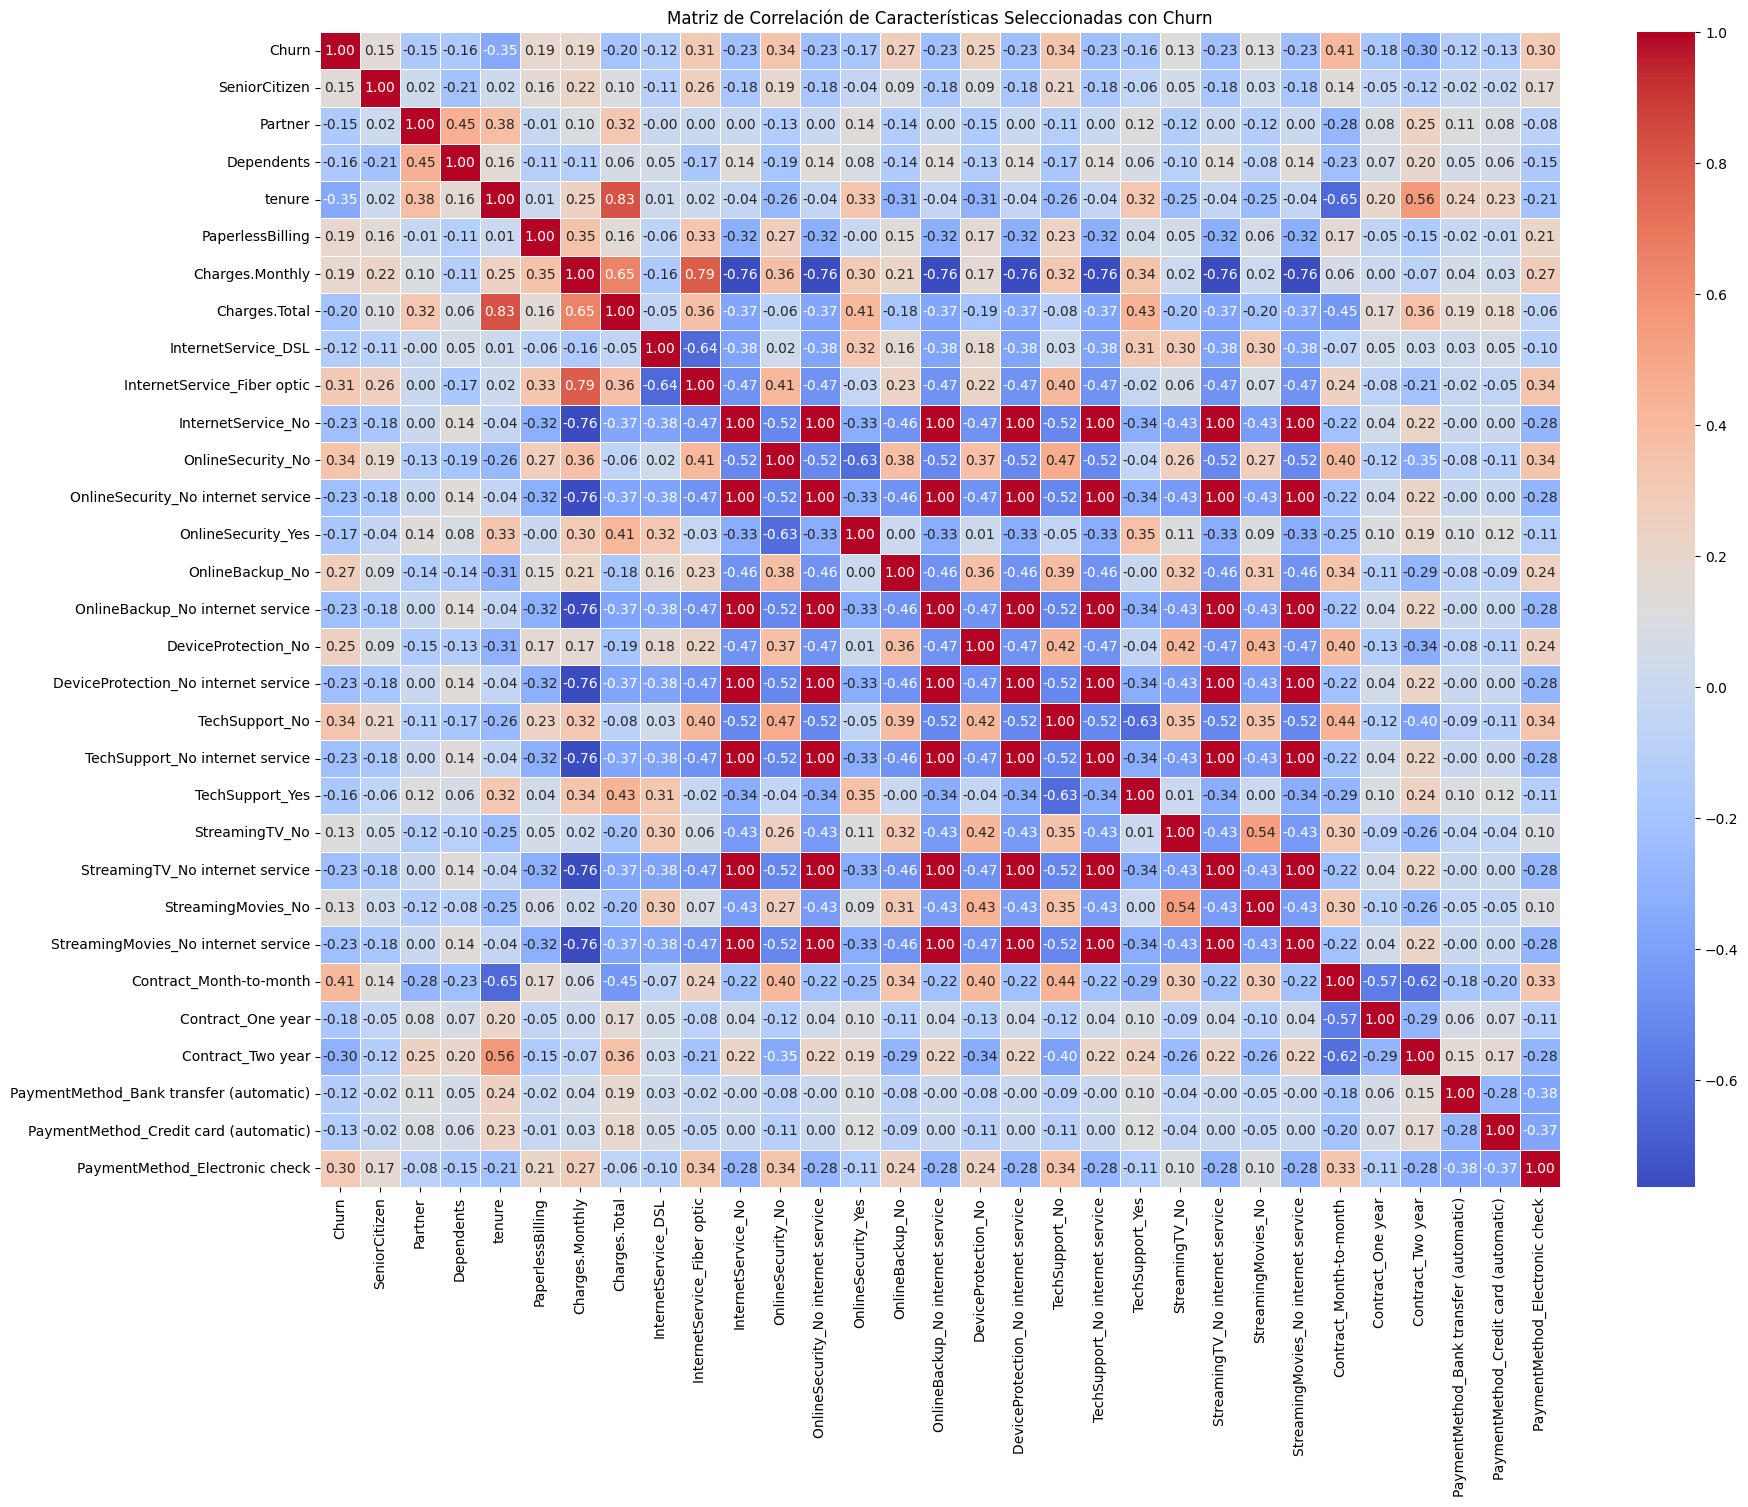

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the target variable with the selected features for correlation analysis
df_selected_corr = pd.concat([y, X_selected], axis=1)

# Calculate the correlation matrix
correlation_matrix = df_selected_corr.corr()

# Plotting the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Características Seleccionadas con Churn')
plt.show()

### Análisis Dirigido: Tiempo de Contrato vs. Cancelación

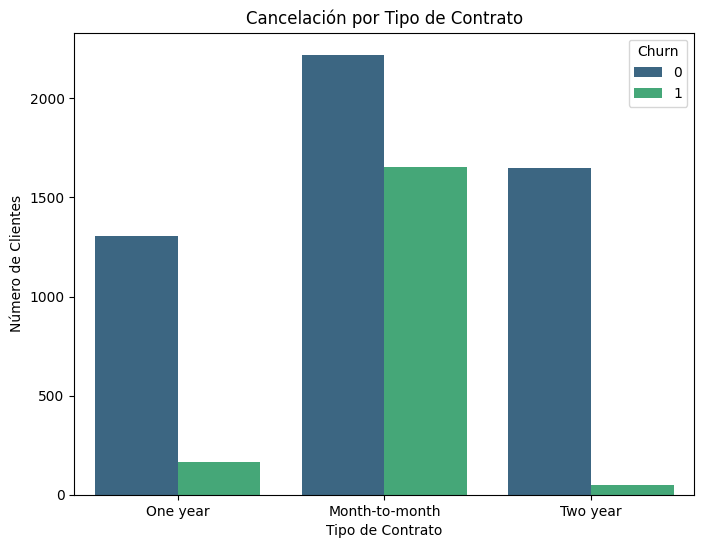

In [45]:
# Create a temporary 'Contract_Type' column from one-hot encoded columns for plotting
dt_temp_plot = dt.copy()
dt_temp_plot['Contract_Type'] = None
dt_temp_plot.loc[dt_temp_plot['Contract_Month-to-month'] == True, 'Contract_Type'] = 'Month-to-month'
dt_temp_plot.loc[dt_temp_plot['Contract_One year'] == True, 'Contract_Type'] = 'One year'
dt_temp_plot.loc[dt_temp_plot['Contract_Two year'] == True, 'Contract_Type'] = 'Two year'

plt.figure(figsize=(8, 6))
sns.countplot(data=dt_temp_plot, x='Contract_Type', hue='Churn', palette='viridis')
plt.title('Cancelación por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.legend(title='Churn')
plt.show()

### Análisis Dirigido: Gasto Total vs. Cancelación

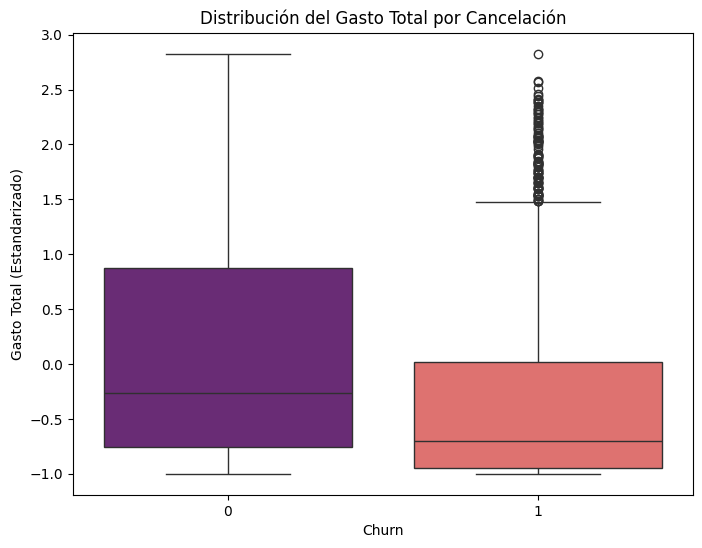

In [46]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=dt, x='Churn', y='Charges.Total', hue='Churn', palette='magma', legend=False)
plt.title('Distribución del Gasto Total por Cancelación')
plt.xlabel('Churn')
plt.ylabel('Gasto Total (Estandarizado)')
plt.show()

### Análisis Dirigido: Antigüedad (Tenure) vs. Cancelación

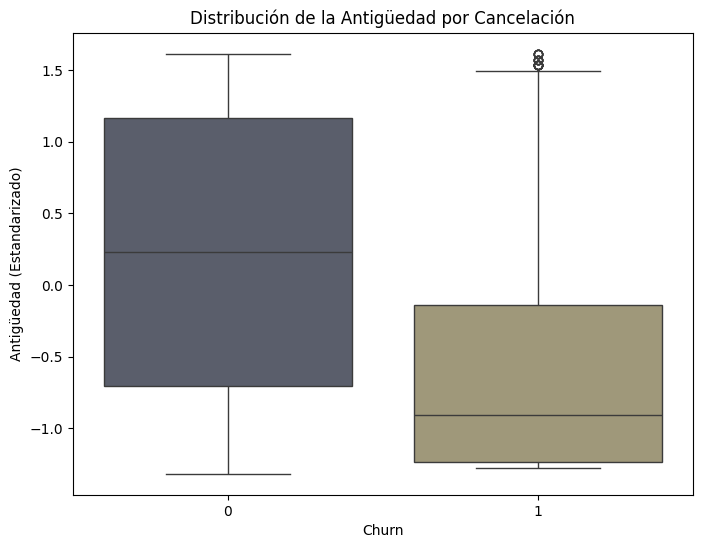

In [47]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=dt, x='Churn', y='tenure', hue='Churn', palette='cividis', legend=False)
plt.title('Distribución de la Antigüedad por Cancelación')
plt.xlabel('Churn')
plt.ylabel('Antigüedad (Estandarizado)')
plt.show()

#**🤖 Modelado Predictivo**

La celda `e6bfcc06` a continuación realiza la separación de los datos en conjuntos de entrenamiento y prueba (80% para entrenamiento y 20% para prueba):

```python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
```

La celda `4c24eb06` a continuación realiza la creación y evaluación de los modelos:

```python
print("\n--- Logistic Regression Model ---")
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)
y_pred_lr = log_reg_model.predict(X_test)
y_pred_proba_lr = log_reg_model.predict_proba(X_test)[:, 1]

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression AUC-ROC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\n--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest AUC-ROC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
```

```python
feature_importance_lr = pd.Series(log_reg_model.coef_[0], index=X_selected.columns)
print("Top 10 features for Logistic Regression (by absolute coefficient value):\n")
print(feature_importance_lr.abs().sort_values(ascending=False).head(10))

feature_importance_rf = pd.Series(rf_model.feature_importances_, index=X_selected.columns)
print("\nTop 10 features for Random Forest (by feature importance value):\n")
print(feature_importance_rf.sort_values(ascending=False).head(10))
```

```python
feature_importance_lr = pd.Series(log_reg_model.coef_[0], index=X_selected.columns)
print("Top 10 features for Logistic Regression (by absolute coefficient value):\n")
print(feature_importance_lr.abs().sort_values(ascending=False).head(10))

feature_importance_rf = pd.Series(rf_model.feature_importances_, index=X_selected.columns)
print("\nTop 10 features for Random Forest (by feature importance value):\n")
print(feature_importance_rf.sort_values(ascending=False).head(10))
```

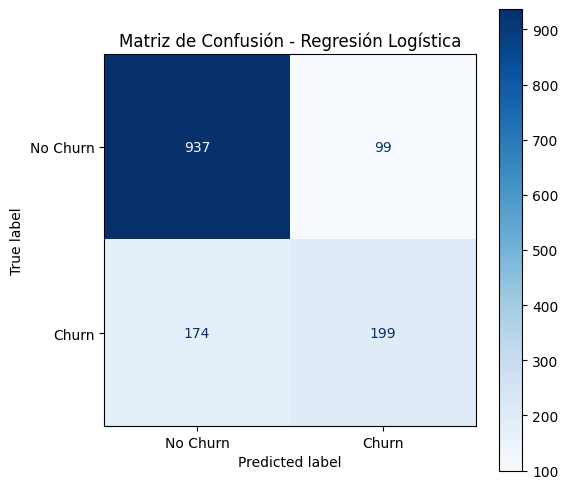

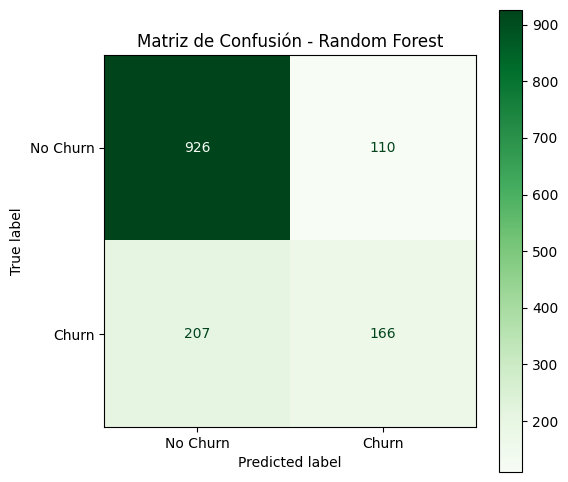

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Churn', 'Churn'])
fig_lr, ax_lr = plt.subplots(figsize=(6, 6))
disp_lr.plot(cmap=plt.cm.Blues, ax=ax_lr)
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn', 'Churn'])
fig_rf, ax_rf = plt.subplots(figsize=(6, 6))
disp_rf.plot(cmap=plt.cm.Greens, ax=ax_rf)
plt.title('Matriz de Confusión - Random Forest')
plt.show()

In [49]:
feature_importance_lr = pd.Series(log_reg_model.coef_[0], index=X_selected.columns)
print("Top 10 features for Logistic Regression (by absolute coefficient value):\n")
print(feature_importance_lr.abs().sort_values(ascending=False).head(10))

feature_importance_rf = pd.Series(rf_model.feature_importances_, index=X_selected.columns)
print("\nTop 10 features for Random Forest (by feature importance value):\n")
print(feature_importance_rf.sort_values(ascending=False).head(10))

Top 10 features for Logistic Regression (by absolute coefficient value):

tenure                                  1.359358
Contract_Two year                       1.019948
InternetService_DSL                     0.764259
Charges.Total                           0.697571
Charges.Monthly                         0.503501
Contract_Month-to-month                 0.494401
StreamingTV_No                          0.409485
DeviceProtection_No internet service    0.408352
StreamingMovies_No internet service     0.408352
StreamingTV_No internet service         0.408352
dtype: float64

Top 10 features for Random Forest (by feature importance value):

Charges.Total                     0.196904
Charges.Monthly                   0.178002
tenure                            0.167725
Contract_Month-to-month           0.057437
PaymentMethod_Electronic check    0.038176
OnlineSecurity_No                 0.030584
InternetService_Fiber optic       0.028184
TechSupport_No                    0.027861
OnlineBack

#**📋 Interpretación y Conclusiones**

Comparación de la Importancia de las Características
La comparación de las 10 características principales de los modelos de Regresión Logística y Bosque Aleatorio revela información común y distintiva sobre la pérdida de clientes:

Factores Clave Comunes:

Antigüedad: Se presenta como un factor muy influyente en ambos modelos, lo que indica que los clientes a largo plazo tienen menos probabilidad de perder (coeficiente negativo en LR, alta importancia en RF). Esto sugiere que la lealtad del cliente se construye con el tiempo.
Cargos Totales y Cargos Mensuales: Ambas características relacionadas con los cargos son significativas para predecir la pérdida de clientes en ambos modelos. Esto implica que el importe total y mensual que se cobra a un cliente influye considerablemente en su decisión de perder.
Contrato Mensual (y viceversa, Contrato de Dos Años / Contrato de Un Año): El tipo de contrato, especialmente los contratos mensuales, es un fuerte predictor de la pérdida de clientes. Los clientes con contratos más cortos y flexibles son más propensos a perder clientes. Diferencias y perspectivas específicas:

La regresión logística destaca las relaciones inversas: enfatiza características como Contrato_Dos años (impacto negativo importante en la pérdida de clientes) y Servicio de Internet_DSL (impacto negativo), Seguridad en línea_No, Soporte técnico_No (impacto positivo). La magnitud de los coeficientes indica directamente la fuerza y ​​la dirección de la relación con la pérdida de clientes.
Random Forest presenta un conjunto más amplio de características significativas: Si bien las principales características son similares, Random Forest también incluye Método de pago_Cheque electrónico, Seguridad en línea_No, Servicio de Internet_Fibra óptica, Soporte técnico_No, Copia de seguridad en línea_No y Facturación electrónica entre sus 10 principales, a menudo con clasificaciones ligeramente diferentes en comparación con la regresión logística. Esto sugiere una interacción más matizada de estas características en el modelo de conjunto.
Interpretación general:

Ambos modelos coinciden en que la antigüedad del cliente, los cargos totales, los cargos mensuales y el tipo de contrato (especialmente el mensual) son los factores más críticos que impulsan la pérdida de clientes. La regresión logística también destaca el impacto de InternetService_DSL (reduciendo la pérdida de clientes) frente a la fibra óptica (aumentándola) y la ausencia de servicios cruciales como OnlineSecurity y TechSupport como indicadores sólidos de pérdida de clientes. El modelo de Bosque Aleatorio corrobora ampliamente estos hallazgos, señalando también PaymentMethod_Electronic check como un factor relevante.

### Hallazgos Clave del Análisis de Datos

* **Preparación de Datos**:
* Los datos anidados de clientes, teléfono, internet y cuentas se extrajeron e integraron correctamente en el DataFrame principal.
* La columna `Charges.Total` se convirtió a tipo numérico y los valores faltantes se imputaron utilizando la mediana.
* Se eliminaron las filas con valores `Churn` vacíos, reduciendo el conjunto de datos de 7267 a 7043 filas.
* Todas las características categóricas se convirtieron a formatos numéricos mediante mapeo binario o codificación one-hot, y las características numéricas (`tenure`, `Charges.Monthly`, `Charges.Total`) se escalaron utilizando `StandardScaler`.
* **Selección de Características**:
* Un análisis de correlación con la variable objetivo `Churn` identificó 30 características con un coeficiente de correlación absoluto de al menos 0,1 como las más relevantes para el entrenamiento del modelo. * Las variables `Contrato_Mes_a-Mes` (0,405), `Antigüedad` (0,352) y `Número_Seguridad_En_Línea` (0,342) mostraron las correlaciones absolutas más altas con la tasa de abandono. Características como `género` y `Servicio_Teléfono` presentaron correlaciones muy bajas (p. ej., `género` con 0,008).
* **Rendimiento del Modelo**:
* **La **Regresión Logística** obtuvo una Precisión de 0,8062, una Precisión de 0,6678, una Recall de 0,5335, una Puntuación F1 de 0,5931 y un AUC-ROC de 0,8408.


* * **El Clasificador de Bosque Aleatorio** alcanzó una Precisión de 0,7750, una Recall de 0,6014, una F1 de 0,4450, una puntuación F1 de 0,5116 y un AUC-ROC de 0,8087.
* El modelo de Regresión Logística, en general, superó al modelo de Bosque Aleatorio en este conjunto de datos en la mayoría de las métricas de evaluación.
* **Factores Clave de Rotación (Importancia de las Características)**:
* Ambos modelos identificaron consistentemente la **`antigüedad`**, **`Cargos Totales`**, **`Cargos Mensuales`** y **`Contrato Mensual`** como los factores más críticos que influyen en la rotación de clientes. * **La regresión logística** destacó el fuerte impacto negativo de `Contrato a dos años` (reduciendo la pérdida de clientes) y `Servicio de Internet DSL`, y el impacto positivo de `Contrato mensual`, `Seguridad en línea sin` y `Soporte técnico sin` (aumentando la pérdida de clientes).
* **Bosque aleatorio** corroboró estos hallazgos y también indicó `Método de pago con cheque electrónico`, `Servicio de Internet con fibra óptica` y `Facturación sin papel` como contribuyentes significativos a la pérdida de clientes.

### Perspectivas o próximos pasos

* **Clientes objetivo con contratos mensuales y cargos altos**: Los clientes con contratos mensuales, especialmente aquellos con cargos mensuales y totales más altos, presentan una probabilidad significativamente mayor de abandono. Las iniciativas de retención deben priorizar estos segmentos mediante ofertas personalizadas o incentivos flexibles para contratos a largo plazo.
* **Mejorar la oferta de servicios y la seguridad**: La ausencia de servicios como seguridad en línea y soporte técnico, y la presencia de internet de fibra óptica (a menudo asociada con mayores costos o expectativas de servicio específicas), son indicadores importantes de abandono. Las empresas deberían considerar promover servicios de valor añadido, mejorar la atención al cliente para problemas técnicos y, quizás, revisar las estrategias de precios de los planes de internet de alta velocidad para reducir la pérdida de clientes en estos grupos.